# Import packages

In [1]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder
#import keras
#from keras.layers import Input, Dense
#from keras.models import Model
#import tensorflow as tf
#from keras.callbacks import History
#from keras.callbacks import CSVLogger
from sklearn.model_selection import train_test_split

# Functions

In [2]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

## dask cluster

In [3]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=1,
        memory='15GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=30GB',
        project='XX',
        walltime='06:00:00')
        #interface='ib0',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [4]:
cluster, client = get_ClusterClient()
#cluster.scale(20) 
cluster.adapt(minimum=0, maximum=50)

In [5]:
cluster

AttributeError: 'Tab' object has no attribute '_ipython_display_'

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.14.4.35:36397,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [1]:
# Close out Dask Cluster and release workers:
# NOTE:  only run this cell to terminate Dask Cluster!
cluster.close()
client.close()

NameError: name 'cluster' is not defined

# Use open_mfdataset on files without time issue

In [3]:
# combine piControl 1 year runs (50 files) into a single 500 year file
# do for various monthly ocean and atmosphere variables
ds_temp_ocn = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_activeTracers_temperature.*.nc'
)

In [4]:
# print variables to check dimensions
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
  * time                                       (time) object 48kB 0001-02-01 ...
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

# Handle files without time coordinate

In [5]:
# utilize functions to process sea surface heights 

#ds_ssh = xr.open_mfdataset(
#    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_ssh.*.nc',
#    preprocess=fixtime,
#    concat_dim='time',
#    combine='nested'
#)

In [6]:
# check file
#ds_ssh

## fix start time 

In [7]:
ds_temp_ocn = ds_temp_ocn.assign_coords(time=ds_temp_ocn['time'] - 
                                        xr.coding.cftime_offsets.MonthBegin(1))
#ds_ssh = ds_ssh.assign_coords(time=ds_ssh['time'] - xr.coding.cftime_offsets.MonthBegin(1))

In [8]:
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
  * time                                       (time) object 48kB 0001-01-01 ...
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [9]:
#ds_ssh

In [10]:
print(ds_temp_ocn['timeMonthly_avg_activeTracers_temperature'].shape) 
      #ds_ssh['timeMonthly_avg_ssh'].shape)

(6000, 60, 180, 360)


# Slice files to Tropical Pacific Region

In [11]:
temp = ds_temp_ocn['timeMonthly_avg_activeTracers_temperature']

In [12]:
#ssh = ds_ssh['timeMonthly_avg_ssh']

In [13]:
temp

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               nVertLevels: 60,
                                                               lat: 180,
                                                               lon: 360)> Size: 93GB
dask.array<concatenate, shape=(6000, 60, 180, 360), dtype=float32, chunksize=(120, 60, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
Dimensions without coordinates: nVertLevels
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [14]:
# new spatial bounds
temp_tp = temp.sel(lat=slice(-10, 10), lon=slice(130, 280))
#ssh_tp = ssh.sel(lat=slice(-10, 10), lon=slice(130, 280))

In [15]:
# only want surface temp!
temp_tp = temp_tp[:,0]

In [16]:
temp_tp.shape

(6000, 20, 150)

In [17]:
# check file
# ssh_tp

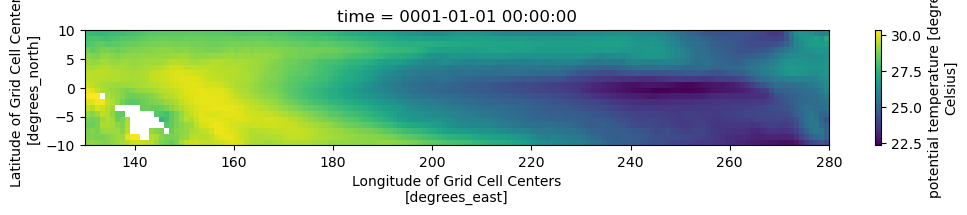

In [18]:
# plot using .pcolormesh() to for sanity check that slice was to tropical pacific region
temp_tp[0].plot.pcolormesh(figsize=(12, 1.5))

In [19]:
# plot using .pcolormesh() to for sanity check that slice was to tropical pacific region
#ssh_tp[0].plot.pcolormesh(figsize=(12, 1.5))

In [20]:
# check shapes
print(temp_tp.shape)
      #, ssh_tp.shape)

(6000, 20, 150)


## check if nan in sst dataset

In [21]:
# Check if there are any NaN values in the sst dataset
has_nan = temp_tp.isnull().any()

print(f"sst dataset contains NaN values: {has_nan.values}")

sst dataset contains NaN values: True


## climatology

In [23]:
sst_climo = temp_tp.groupby('time.month').mean(dim='time', keep_attrs=True)

In [24]:
sst_climo

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (month: 12,
                                                               lat: 20, lon: 150)> Size: 144kB
dask.array<stack, shape=(12, 20, 150), dtype=float32, chunksize=(1, 20, 150), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -9.5 -8.5 -7.5 -6.5 -5.5 ... 5.5 6.5 7.5 8.5 9.5
  * lon      (lon) float64 1kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [25]:
sst_anom = temp_tp.groupby('time.month') - sst_climo

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/xarray/core/indexing.py:1621: PerformanceWarning: Slicing with an out-of-order index is generating 500 times more chunks
  return self.array[key]


In [26]:
sst_anom

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 20, lon: 150)> Size: 72MB
dask.array<sub, shape=(6000, 20, 150), dtype=float32, chunksize=(1, 20, 150), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -9.5 -8.5 -7.5 -6.5 -5.5 ... 5.5 6.5 7.5 8.5 9.5
  * lon      (lon) float64 1kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

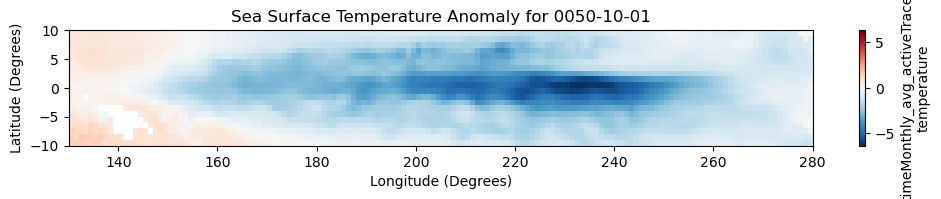

In [27]:
sst_anom[597].plot.pcolormesh(figsize=(12, 1.5), cmap='RdBu_r')
plt.title('Sea Surface Temperature Anomaly for 0050-10-01')
plt.xlabel('Longitude (Degrees)')
plt.ylabel('Latitude (Degrees)')
plt.show()

## how to do grid reconstruction [from Maria]

In [28]:
def create_index_mask(da):
    """
    Create index mask for reconstruction of predictions.
    Args:
        da (xarray data array): 2d input variable samples
    Returns:
        y_, x_ (numpy arrays): x and y indices for reconstruction
    """
    # just one sample needed; time=0
    da = da.isel(time=0)
    
    # original 2d grid shape
    orig_2d_shape = da.shape
    
    # location of the valid values (not nan) in 1d vector
    orig_indx = np.where(~np.isnan(da.stack(newdim=['lat', 'lon']).values))[0]
    
    # Indices of non-nan values in original 2d grid
    y_, x_ = np.unravel_index(orig_indx, orig_2d_shape)
    
    # return the respective indices for (20, 150)
    return y_, x_

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d.values
    
    # return predictions on original 2d grid
    return pred_grid

In [29]:
# produce the indices to be used
y_vals, x_vals = create_index_mask(sst_anom)

# save the numpy arrays of the y, x indices
np.save('sst_yindx.npy', y_vals)
np.save('sst_xindx.npy', x_vals)

In [30]:
# indices can be loaded anytime and used for reconstruction
yindx = np.load('sst_yindx.npy')
xindx = np.load('sst_xindx.npy')

### fake predictions here just using actual data
# flattened grid shape
sst_newdim = sst_anom.stack(newdim=['lat', 'lon'])
# flattened grid shape after dropping nans
sst_processed = sst_newdim.dropna('newdim', how='any')

# now reconstruct fake predictions
predictions_2d = reconstruct_grid(sst_processed, yindx, xindx)

# can close files like this
del yindx
del xindx

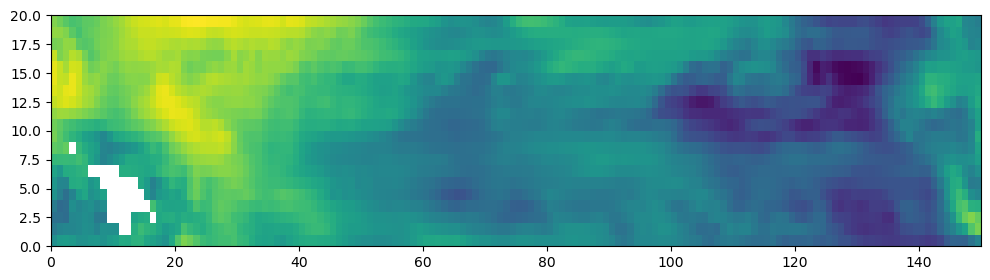

In [31]:
# quick viz of reconstruction
plt.figure(figsize=(12,3))
plt.pcolormesh(predictions_2d[0,:,:])
plt.show()

## stack dims

In [34]:
sst_newdim = sst_anom.stack(newdim=['lat', 'lon'])

In [35]:
sst_newdim.shape

(6000, 3000)

In [36]:
sst_newdim

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               newdim: 3000)> Size: 72MB
dask.array<reshape, shape=(6000, 3000), dtype=float32, chunksize=(1, 3000), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [37]:
sst_processed = sst_newdim.dropna('newdim', how='all')
sst_processed = sst_newdim.dropna('newdim', how='any')

In [38]:
sst_processed

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               newdim: 2968)> Size: 71MB
dask.array<getitem, shape=(6000, 2968), dtype=float32, chunksize=(1, 2968), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [39]:
sst_processed.shape

(6000, 2968)

In [40]:
has_nan = sst_processed.isnull().any().compute().item()
print(has_nan)

False


# Split into test and train 

In [41]:
sst_train, sst_test = train_test_split(
    sst_processed, test_size=0.2, random_state=0, shuffle=True
)

In [42]:
# check shapes of train and test data 
print(sst_train.shape, 
      sst_test.shape)

(4800, 2968) (1200, 2968)


## RobustScaler()

In [43]:
from sklearn.preprocessing import RobustScaler

sst_train_tmp = sst_train.copy()
sst_train_tmp = sst_train_tmp.values

scaler_tmp = RobustScaler()
scaler_tmp_sst = scaler_tmp.fit(sst_train_tmp.reshape(4800 * 2968, 1))

In [44]:
scaler = RobustScaler()

scaler_sst = scaler.fit(sst_train)

In [45]:
scaler_sst.center_ = np.repeat(scaler_tmp_sst.center_, 2968)

In [46]:
scaler_sst.scale_ = np.repeat(scaler_tmp_sst.scale_, 2968)

In [47]:
scaled_input_sst_train = scaler_sst.transform(sst_train)

scaled_input_sst_test = scaler_sst.transform(sst_test)

print(scaled_input_sst_train.shape, scaled_input_sst_test.shape)

(4800, 2968) (1200, 2968)


In [48]:
import joblib

# Save the scaler to a file
joblib.dump(scaler_sst, 'scaler_sst.pkl')

print("Scaler saved successfully!")

Scaler saved successfully!


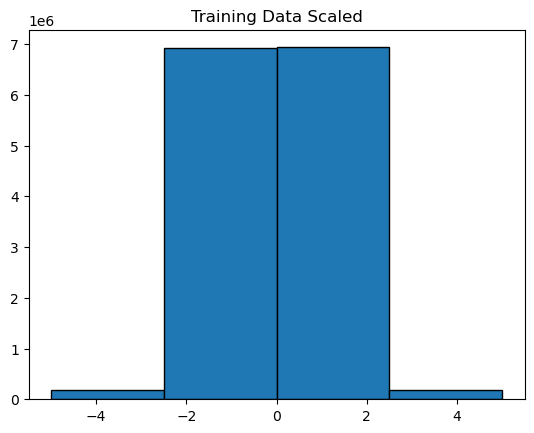

In [49]:
plt.hist(scaled_input_sst_train.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('Training Data Scaled')
plt.show()

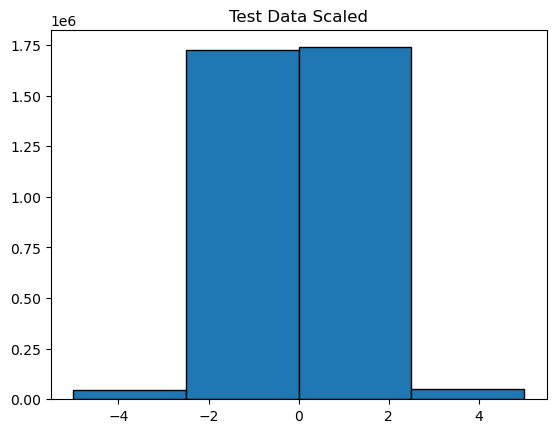

In [50]:
plt.hist(scaled_input_sst_test.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('Test Data Scaled')
plt.show()

## RETAIN TIME COMPONENT FOR SORTING LATER ON

In [51]:
scaled_input_sst_train.shape

(4800, 2968)

In [52]:
scaled_input_sst_test.shape

(1200, 2968)

In [53]:
import xarray as xr

# Get original coordinates for each dimension
coords = sst_train.coords  # Retains 'time', 'lat', 'lon', etc.
dims = sst_train.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
sst_train_coords = xr.DataArray(scaled_input_sst_train, dims=dims, coords=coords)

In [54]:
sst_train_coords

<xarray.DataArray (time: 4800, newdim: 2968)> Size: 57MB
array([[-0.07861855, -0.14215587, -0.19736274, ..., -0.10560908,
        -0.13798559, -0.16396768],
       [-0.08183599, -0.04659336, -0.07935404, ..., -0.1433286 ,
        -0.1426007 , -0.21731941],
       [-0.6227208 , -0.7048019 , -0.53963375, ..., -0.06147998,
        -0.0683066 , -0.07550474],
       ...,
       [ 0.10856619,  0.20029962,  0.32955796, ...,  0.2720966 ,
         0.37365422,  0.38912216],
       [-0.7562657 , -0.7464516 , -0.6627403 , ..., -0.06114889,
        -0.05420854, -0.13564518],
       [-0.11224867, -0.02304267,  0.20995192, ...,  0.26840404,
         0.3020771 ,  0.39176837]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [55]:
# Get original coordinates for each dimension
coords = sst_test.coords  # Retains 'time', 'lat', 'lon', etc.
dims = sst_test.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
sst_test_coords = xr.DataArray(scaled_input_sst_test, dims=dims, coords=coords)

In [56]:
sst_test_coords

<xarray.DataArray (time: 1200, newdim: 2968)> Size: 14MB
array([[-0.46359065, -0.60571617, -0.77645487, ...,  0.09887093,
         0.07388971,  0.01491442],
       [-0.37649506, -0.3998309 , -0.54369783, ..., -0.11884276,
        -0.1317959 , -0.10782312],
       [ 0.24239667,  0.18229668,  0.16628028, ..., -0.19123118,
        -0.21989487, -0.2408524 ],
       ...,
       [ 0.3562983 ,  0.39527646,  0.49703625, ...,  0.06569828,
         0.08118138, -0.0373126 ],
       [ 0.35452402,  0.39845094,  0.45944312, ..., -0.24596794,
        -0.1585084 , -0.07985194],
       [ 0.23833507,  0.24282634,  0.26705185, ...,  0.36038768,
         0.36764395,  0.30015373]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [57]:
print(sst_train_coords.shape, sst_test_coords.shape)

(4800, 2968) (1200, 2968)


In [58]:
# Convert MultiIndex levels in `newdim` into separate coordinates
sst_train_reset_index = sst_train_coords.reset_index('newdim')

In [59]:
sst_train_reset_index

<xarray.DataArray (time: 4800, newdim: 2968)> Size: 57MB
array([[-0.07861855, -0.14215587, -0.19736274, ..., -0.10560908,
        -0.13798559, -0.16396768],
       [-0.08183599, -0.04659336, -0.07935404, ..., -0.1433286 ,
        -0.1426007 , -0.21731941],
       [-0.6227208 , -0.7048019 , -0.53963375, ..., -0.06147998,
        -0.0683066 , -0.07550474],
       ...,
       [ 0.10856619,  0.20029962,  0.32955796, ...,  0.2720966 ,
         0.37365422,  0.38912216],
       [-0.7562657 , -0.7464516 , -0.6627403 , ..., -0.06114889,
        -0.05420854, -0.13564518],
       [-0.11224867, -0.02304267,  0.20995192, ...,  0.26840404,
         0.3020771 ,  0.39176837]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [60]:
# Convert MultiIndex levels in `newdim` into separate coordinates
sst_test_reset_index = sst_test_coords.reset_index('newdim')

In [61]:
sst_test_reset_index

<xarray.DataArray (time: 1200, newdim: 2968)> Size: 14MB
array([[-0.46359065, -0.60571617, -0.77645487, ...,  0.09887093,
         0.07388971,  0.01491442],
       [-0.37649506, -0.3998309 , -0.54369783, ..., -0.11884276,
        -0.1317959 , -0.10782312],
       [ 0.24239667,  0.18229668,  0.16628028, ..., -0.19123118,
        -0.21989487, -0.2408524 ],
       ...,
       [ 0.3562983 ,  0.39527646,  0.49703625, ...,  0.06569828,
         0.08118138, -0.0373126 ],
       [ 0.35452402,  0.39845094,  0.45944312, ..., -0.24596794,
        -0.1585084 , -0.07985194],
       [ 0.23833507,  0.24282634,  0.26705185, ...,  0.36038768,
         0.36764395,  0.30015373]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [62]:
# Save the xarray DataArray to a NetCDF file
sst_train = sst_train_reset_index.to_netcdf('sst_train_robustscaler.nc')
sst_test = sst_test_reset_index.to_netcdf('sst_test_robustscaler.nc')

# Save out file

In [65]:
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

In [66]:
# sst train and test
savetxt('sst_train_robustscaler.csv',
        scaled_input_sst_train, delimiter=',')
savetxt('sst_test_robustscaler.csv',
        scaled_input_sst_test, delimiter=',')